<a href="https://colab.research.google.com/github/farhanwew/Information-retrieval/blob/main/Cisi%20dataset%20%7C%20agent%20yandex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Agentic Retrieval**

Team 4 Information Retrieval Assignment 1 Notebook

|Name|Student ID|
|:--:|:--:|
|Faiz Muhammad Kautsar|5054231013|
|Muhammad Rasyad Lubis|5054231010|
|Muhammad Farhan Arya Wicaksono|5054231011|
|Ahnaf Tsabit Attaqi|5054231012|
|Efan Ramdhani|5054231017|

For this assignment, since we were tasked with the application of an information retrieval pipeline with methods we found on the internet, we've decided on the implementation of a full agentic-based information retrieval pipeline to compare the neural embedding/reranking methods of SPLADE along with the BGE suite of ColBERT, Sparse, Dense, and Reranker (this is a Cross-Encoder model) for the Reranking and Retrieval of relevant documents from the Duckduckgo search engine.

Note that though this *does* use a generative agentic system, it is ***not*** an RAG mechanism. This is because the generative process here is utilized to refine and reconstruct the semantic query to then be shot to the ddg API. Reranking is then done our end via the models, and then top-3 are then assessed for sufficiency in answering the question.

The flow of the pipeline roughly goes as follows:


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dmaso01dsta/cisi-a-dataset-for-information-retrieval")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cisi-a-dataset-for-information-retrieval' dataset.
Path to dataset files: /kaggle/input/cisi-a-dataset-for-information-retrieval


In [ ]:
!ls $path

CISI.ALL  CISI.QRY  CISI.REL


In [ ]:
!pip install "transformers<5"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 143.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip install FlagEmbedding

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.6 MB/s eta 0:00:00
  Created wheel for FlagEmbedding: filename=FlagEmbedding-1.3.5-py3-none-any.whl size=233746 sha256=a754555039ee79bfbea50904186aa4d4dd796d3536de11f1437c3315986884b0
  Stored in directory: /root/.cache/pip/wheels/b2/1f/f6/78f862bb80cb959cc9960b7c4e2d1f702b1bc0e79d19b5f124
  Created wheel for warc3-wet-clueweb09: filename=warc3_wet_clueweb09-0.2.5-py3-none-any.whl size=18919 sha256=cfe80524c9c53a689b8c1f08fa7b58f626178535f0240953a081900139061e42
  Stored in directory: /root/.c

In [ ]:
%pip install rank-bm25

In [ ]:
!pip install python-dotenv

In [ ]:
from google.colab import userdata

with open('.env', 'w') as f:
    f.write(f"OPENROUTER_API_KEY={userdata.get('OPENROUTER_API_KEY')}")

In [ ]:
%%writefile retrieval_comparison.py
import os
from dotenv import load_dotenv

load_dotenv()
OPENROUTER_API_KEY = os.environ.get('OPENROUTER_API_KEY', '')

import asyncio
import urllib.parse
import httpx
import torch
import numpy as np
import json
from typing import List, Dict
from openai import AsyncOpenAI

openai_client = AsyncOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

from FlagEmbedding import BGEM3FlagModel, FlagReranker
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, util as st_util

from transformers import AutoModelForMaskedLM, AutoTokenizer

class RetrievalQueue:
    def __init__(self):
        self._queue = asyncio.Queue()
        self._worker_task = None

    async def start(self):
        if self._worker_task is None:
            self._worker_task = asyncio.create_task(self._worker())

    async def stop(self):
        if self._worker_task:
            self._worker_task.cancel()
            try:
                await self._worker_task
            except asyncio.CancelledError:
                pass
            self._worker_task = None

    async def retrieve(self, query: str) -> List[Dict]:
        """Submit a query to the queue and wait for its result."""
        loop = asyncio.get_running_loop()
        future = loop.create_future()
        await self._queue.put((query, future))
        return await future

    async def _worker(self):
        async with httpx.AsyncClient(timeout=30.0) as client:
            while True:
                batch = [await self._queue.get()]

                while len(batch) < 3 and not self._queue.empty():
                    batch.append(self._queue.get_nowait())

                async def process_item(item):
                    query, future = item
                    try:
                        results = await self._perform_search(client, query)
                        future.set_result(results)
                    except Exception as e:
                        future.set_exception(e)
                    finally:
                        self._queue.task_done()

                await asyncio.gather(*(process_item(item) for item in batch))
                await asyncio.sleep(1)

    async def _perform_search(self, client: httpx.AsyncClient, query: str) -> List[Dict]:
        encoded_query = urllib.parse.quote(query)
        url = f"https://4get.canine.tools/api/v1/web?s={encoded_query}&scraper=yandex&nsfw=yes"

        response = await client.get(url)
        response.raise_for_status()
        data = response.json()

        answers = data.get("answer", [])
        webs = data.get("web", [])

        all_results = [*answers, *webs]
        formatted_results = []

        for r in all_results:
            desc = r.get("description", "")
            if isinstance(desc, list):
                if len(desc) > 0 and isinstance(desc[0], dict):
                    desc = desc[0].get("value", "")
                else:
                    desc = str(desc)

            # skip empty docs
            if not desc.strip():
                continue

            formatted_results.append({
                "title": r.get("title", query),
                "description": desc,
                "url": r.get("url", ""),
            })

        return formatted_results


# global queue
search_queue = RetrievalQueue()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# model globals
splade_tokenizer = None
splade_model = None
bge_m3 = None
reranker = None
st_model = None
current_loaded_model = None

def load_model_for_method(method):
    global splade_tokenizer, splade_model, bge_m3, reranker, st_model, current_loaded_model
    import gc

    req = None
    if method == "splade": req = "splade"
    elif method in ["bge_dense", "bge_sparse", "bge_colbert", "bge_hybrid"]: req = "bge_m3"
    elif method == "bge_reranker": req = "bge_reranker"
    elif method == "bm25_rerank": req = "st"

    if current_loaded_model == req:
        return # already loaded!

    print(f"\n[system] switching models: unloading {current_loaded_model}, loading {req}...")

    # nuke current model from vram
    splade_tokenizer = None
    splade_model = None
    bge_m3 = None
    reranker = None
    st_model = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # load the new one
    if req == "splade":
        splade_model_id = 'naver/splade-cocondenser-ensembledistil'
        splade_tokenizer = AutoTokenizer.from_pretrained(splade_model_id)
        splade_model = AutoModelForMaskedLM.from_pretrained(splade_model_id).to(device)
        splade_model.eval()
    elif req == "bge_m3":
        bge_m3 = BGEM3FlagModel('BAAI/bge-m3', use_fp16=True, device=device)
    elif req == "bge_reranker":
        reranker = FlagReranker('BAAI/bge-reranker-v2-m3', use_fp16=True, device=device)
    elif req == "st":
        st_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)

    current_loaded_model = req

def get_splade_vecs(texts, batch_size=32):
    all_vecs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            tokens = splade_tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=512).to(device)
            output = splade_model(**tokens)

            # max pooling over the sequence tokens
            vecs = torch.max(
                torch.log(1 + torch.relu(output.logits)) * tokens.attention_mask.unsqueeze(-1),
                dim=1
            )[0]
            # yeet to cpu immediately so vram doesn't cry
            all_vecs.append(vecs.cpu())

    return torch.cat(all_vecs, dim=0)

def precompute_corpus(docs: List[Dict], method: str) -> dict:
    if not docs: return {}
    load_model_for_method(method)
    passages = [d["description"] for d in docs]

    cache = {}
    if method == "splade":
        cache['vecs'] = get_splade_vecs(passages)
    elif method == "bge_reranker":
        # cross encoders process Q+D together, so we cant pre-cache docs individually sadly
        pass
    elif method == "bm25_rerank":
        tokenized_passages = [p.lower().split() for p in passages]
        cache['bm25'] = BM25Okapi(tokenized_passages)
        # save vram by tossing the embeddings to cpu
        cache['st_embs'] = st_model.encode(passages, convert_to_tensor=True).cpu()
    elif method.startswith("bge_"):
        cache['bge_out'] = bge_m3.encode(passages, return_dense=True, return_sparse=True, return_colbert_vecs=True)

    return cache

def fast_rank_docs(query: str, docs: List[Dict], cache: dict, method: str) -> List[Dict]:
    if not docs: return []
    load_model_for_method(method)
    passages = [d["description"] for d in docs]

    if method == "splade":
        q_vec = get_splade_vecs([query])
        scores = torch.matmul(q_vec, cache['vecs'].T).squeeze().cpu().numpy()
        if scores.ndim == 0: scores = [scores.item()]

    elif method == "bge_reranker":
        pairs = [[query, p] for p in passages]
        scores = reranker.compute_score(pairs)
        if isinstance(scores, float): scores = [scores]

    elif method == "bm25_rerank":
        q_tokens = query.lower().split()
        bm25_raw_scores = cache['bm25'].get_scores(q_tokens)

        top_k = min(10, len(passages))
        top_bm25_idx = sorted(range(len(bm25_raw_scores)), key=lambda i: bm25_raw_scores[i], reverse=True)[:top_k]

        candidate_embs = cache['st_embs'][top_bm25_idx].to(device)
        q_emb = st_model.encode(query, convert_to_tensor=True)
        cos_scores_raw = st_util.cos_sim(q_emb, candidate_embs)[0].cpu().tolist()

        score_map = {top_bm25_idx[j]: cos_scores_raw[j] for j in range(len(top_bm25_idx))}
        scores = [score_map.get(i, 0.0) for i in range(len(passages))]

    else:
        q_out = bge_m3.encode([query], return_dense=True, return_sparse=True, return_colbert_vecs=True)
        d_out = cache['bge_out']

        if method == "bge_dense":
            scores = (q_out['dense_vecs'] @ d_out['dense_vecs'].T)[0]
        elif method == "bge_sparse":
            scores = [bge_m3.compute_lexical_matching_score(q_out['lexical_weights'][0], d_out['lexical_weights'][i]) for i in range(len(passages))]
        elif method == "bge_colbert":
            scores = [bge_m3.colbert_score(q_out['colbert_vecs'][0], d_out['colbert_vecs'][i]).item() for i in range(len(passages))]
        elif method == "bge_hybrid":
            scores = []
            # optimize slightly by doing all dense scores in one fast matrix op first
            dense_scores = (q_out['dense_vecs'] @ d_out['dense_vecs'].T)[0]
            for i in range(len(passages)):
                s_dense = dense_scores[i]
                s_lex = bge_m3.compute_lexical_matching_score(q_out['lexical_weights'][0], d_out['lexical_weights'][i])
                s_colbert = bge_m3.colbert_score(q_out['colbert_vecs'][0], d_out['colbert_vecs'][i]).item()
                scores.append((s_dense + s_lex + s_colbert) / 3.0)
        else:
            scores = [0] * len(passages)

    ranked = []
    for i, score in enumerate(scores):
        d = docs[i].copy()
        d['score'] = float(score)
        ranked.append(d)

    ranked.sort(key=lambda x: x['score'], reverse=True)
    return ranked

def rank_docs(query: str, docs: List[Dict], method: str) -> List[Dict]:
    if not docs: return []

    # auto-load the model if it's not loaded yet so external imports don't crash
    load_model_for_method(method)

    passages = [d["description"] for d in docs]

    if method == "splade":
        q_vec = get_splade_vecs([query])
        d_vecs = get_splade_vecs(passages)
        # get_splade_vecs now returns cpu tensors, so we can just matmul and numpy it
        scores = torch.matmul(q_vec, d_vecs.T).squeeze().numpy()
        if scores.ndim == 0: scores = [scores.item()]

    elif method == "bge_reranker":
        pairs = [[query, p] for p in passages]
        scores = reranker.compute_score(pairs)
        if isinstance(scores, float): scores = [scores]

    elif method == "bm25_rerank":
        # Stage 1 – BM25 first-pass on the live web-retrieved docs
        tokenized_passages = [p.lower().split() for p in passages]
        q_tokens = query.lower().split()
        bm25_index = BM25Okapi(tokenized_passages)
        bm25_raw_scores = bm25_index.get_scores(q_tokens)

        # Keep top-K candidates (at most 10 or all docs)
        top_k = min(10, len(passages))
        top_bm25_idx = sorted(range(len(bm25_raw_scores)),
                              key=lambda i: bm25_raw_scores[i], reverse=True)[:top_k]
        candidate_passages = [passages[i] for i in top_bm25_idx]
        candidate_docs_subset = [docs[i] for i in top_bm25_idx]

        # Stage 2 – Semantic reranking with sentence-transformer
        q_emb = st_model.encode(query, convert_to_tensor=True)
        c_embs = st_model.encode(candidate_passages, convert_to_tensor=True)
        cos_scores_raw = st_util.cos_sim(q_emb, c_embs)[0].cpu().tolist()

        # Return all docs with score; non-candidates get 0
        score_map = {top_bm25_idx[j]: cos_scores_raw[j] for j in range(len(top_bm25_idx))}
        scores = [score_map.get(i, 0.0) for i in range(len(passages))]

    else:
        # bge-m3 variants
        q_out = bge_m3.encode([query], return_dense=True, return_sparse=True, return_colbert_vecs=True)
        d_out = bge_m3.encode(passages, return_dense=True, return_sparse=True, return_colbert_vecs=True)

        if method == "bge_dense":
            scores = (q_out['dense_vecs'] @ d_out['dense_vecs'].T)[0]
        elif method == "bge_sparse":
            scores = [bge_m3.compute_lexical_matching_score(q_out['lexical_weights'][0], d_out['lexical_weights'][i]) for i in range(len(passages))]
        elif method == "bge_colbert":
            scores = [bge_m3.colbert_score(q_out['colbert_vecs'][0], d_out['colbert_vecs'][i]).item() for i in range(len(passages))]
        elif method == "bge_hybrid":
            scores = []
            for i in range(len(passages)):
                s_dense = (q_out['dense_vecs'] @ d_out['dense_vecs'].T)[0][i]
                s_lex = bge_m3.compute_lexical_matching_score(q_out['lexical_weights'][0], d_out['lexical_weights'][i])
                s_colbert = bge_m3.colbert_score(q_out['colbert_vecs'][0], d_out['colbert_vecs'][i]).item()
                scores.append((s_dense + s_lex + s_colbert) / 3.0)
        else:
            scores = [0] * len(passages)

    # sort docs by their new score
    ranked = []
    for i, score in enumerate(scores):
        d = docs[i].copy()
        d['score'] = float(score)
        ranked.append(d)

    ranked.sort(key=lambda x: x['score'], reverse=True)
    return ranked

async def agent_step(original_query: str, current_search: str, docs: List[Dict]) -> tuple[bool, str, str]:
    """ask an openrouter model to evaluate docs and decide on the next search query."""
    if not OPENROUTER_API_KEY:
        return False, "no openrouter api key found. set OPENROUTER_API_KEY in your .env file.", ""

    if not docs:
        context = "No documents found for this search."
    else:
        context = "\n\n".join([f"doc {i+1}:\n{d['description']}" for i, d in enumerate(docs)])

    prompt = f"""You are an autonomous AI agent trying to answer a user's query.
Original Query: "{original_query}"

Current Search Used: "{current_search}"

Retrieved Documents:
{context}

Based ONLY on the documents above, do you have enough information to answer the original query?
If YES, respond with JSON: {{"answered": true, "thought": "your reasoning"}}
If NO, formulate a NEW search query to find the missing information. Respond with JSON: {{"answered": false, "thought": "what is missing", "next_search_query": "your new query"}}
"""

    try:
        response = await openai_client.chat.completions.create(
            model="meta-llama/llama-3.1-8b-instruct",
            messages=[{"role": "user", "content": prompt}],
            response_format={"type": "json_object"}
        )

        content = response.choices[0].message.content
        result = json.loads(content)
        return bool(result.get('answered', False)), str(result.get('thought', "failed to parse thought.")), str(result.get('next_search_query', ""))
    except Exception as e:
        return False, f"api error: {str(e)}", ""

async def run_agent_trace(original_query: str, method: str, max_steps: int = 4):
    trace = []
    current_search = original_query

    for step in range(max_steps):
        raw_docs = await search_queue.retrieve(current_search)

        # rank docs against the *current* search intent and take top 3
        ranked_docs = rank_docs(current_search, raw_docs, method)
        top_ranked = ranked_docs[:3]

        # let the agent evaluate and decide next moves
        is_answered, thought, next_search = await agent_step(original_query, current_search, top_ranked)

        raw_titles = [f"{d.get('title', '')[:45]}..." for d in raw_docs[:3]] if raw_docs else ["No docs found"]
        ranked_titles = [f"{d.get('title', '')[:45]}..." for d in top_ranked] if top_ranked else ["No docs found"]

        trace.append({
            "step": step + 1,
            "search_query": current_search,
            "top_score": top_ranked[0]['score'] if top_ranked else 0.0,
            "thought": thought,
            "answered": is_answered,
            "raw_order": raw_titles,
            "ranked_order": ranked_titles
        })

        if is_answered:
            break

        # use the agent's new search query, fallback if it bugs out
        current_search = next_search if next_search else f"{original_query} more details"

    return trace

async def run_comparison(test_queries: List[str]):
    methods = ["splade", "bge_dense", "bge_sparse", "bge_colbert", "bge_hybrid", "bge_reranker", "bm25_rerank"]

    await search_queue.start()

    # loop methods on the outside so we don't swap models constantly
    for method in methods:
        print(f"\n{'='*60}")
        print(f" testing method: '{method}'")
        print(f"{'='*60}")

        load_model_for_method(method)

        for query in test_queries:
            print(f"\n  -> running trace for query: '{query}'")
            trace = await run_agent_trace(query, method)

            print(f"     finished in {len(trace)} steps. answered: {trace[-1]['answered'] if trace else False}")
            for t in trace:
                print(f"       [step {t['step']}] query: '{t['search_query']}' | top score: {t['top_score']:.4f}")
                print(f"         raw retrieved : {t['raw_order']}")
                print(f"         after ranking : {t['ranked_order']}")
                print(f"         thought       : {t['thought']}")

async def main():
    try:
        test_queries = [
            "difference between sparse and dense vector search", # Dense is latent/semantic, sparse are often more just statistical
            "how does splade handle vocabulary mismatch", # Term Expansion by the encoder
            "who developed the bge-m3 embedding model", # BAAI
            "who is the pink-haired girl in fate grand order" # Astolfo
        ]
        await run_comparison(test_queries)
    finally:
        await search_queue.stop()

if __name__ == "__main__":
    asyncio.run(main())

Writing retrieval_comparison.py


In [ ]:
%%writefile bench.py
import os
import math
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

# import your existing code so we use your exact logic
import retrieval_comparison as rc

def load_cisi_docs(filepath):
    docs = []
    current_doc = {}
    current_tag = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('.'):
                tag = line.strip()
                if tag.startswith('.I'):
                    if current_doc:
                        docs.append(current_doc)
                    # format matches what rank_docs expects
                    current_doc = {'id': tag.split()[1], 'title': '', 'description': ''}
                    current_tag = None
                else:
                    current_tag = tag
            else:
                if current_tag == '.T':
                    current_doc['title'] += line.strip() + ' '
                elif current_tag == '.W':
                    current_doc['description'] += line.strip() + ' '

    if current_doc:
        docs.append(current_doc)

    # clean up extra whitespace
    for d in docs:
        d['title'] = d['title'].strip()
        d['description'] = d['description'].strip()

    return docs

def load_cisi_queries(filepath):
    queries = {}
    current_qid = None
    current_tag = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('.'):
                tag = line.strip()
                if tag.startswith('.I'):
                    current_qid = tag.split()[1]
                    queries[current_qid] = ""
                    current_tag = None
                else:
                    current_tag = tag
            else:
                if current_tag == '.W':
                    queries[current_qid] += line.strip() + ' '

    for qid in queries:
        queries[qid] = queries[qid].strip()

    return queries

def load_cisi_qrels(filepath):
    qrels = defaultdict(set)
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                qid, docid = parts[0], parts[1]
                qrels[qid].add(docid)
    return qrels

def compute_metrics(ranked_ids, relevant_docs, k=10):
    """calculates mrr, recall@k, precision@k, map, and ndcg@k."""
    top_k = ranked_ids[:k]

    # recall & precision @ k
    hits_in_k = len(set(top_k).intersection(relevant_docs))
    recall = hits_in_k / len(relevant_docs) if relevant_docs else 0.0
    precision = hits_in_k / k

    # mrr
    mrr = 0.0
    for rank, doc_id in enumerate(ranked_ids, 1):
        if doc_id in relevant_docs:
            mrr = 1.0 / rank
            break

    # map (mean average precision)
    num_hits = 0
    sum_precisions = 0.0
    for i, doc_id in enumerate(ranked_ids, 1):
        if doc_id in relevant_docs:
            num_hits += 1
            sum_precisions += num_hits / i
    map_score = sum_precisions / len(relevant_docs) if relevant_docs else 0.0

    # ndcg@k
    dcg = 0.0
    for i, doc_id in enumerate(top_k, 1):
        if doc_id in relevant_docs:
            dcg += 1.0 / math.log2(i + 1)

    idcg = 0.0
    for i in range(1, min(len(relevant_docs), k) + 1):
        idcg += 1.0 / math.log2(i + 1)

    ndcg = dcg / idcg if idcg > 0 else 0.0

    return {"mrr": mrr, f"recall@{k}": recall, f"precision@{k}": precision, "map": map_score, f"ndcg@{k}": ndcg}

def main():
    print("downloading cisi dataset...")
    data_path = kagglehub.dataset_download("dmaso01dsta/cisi-a-dataset-for-information-retrieval")

    docs_path = os.path.join(data_path, "CISI.ALL")
    queries_path = os.path.join(data_path, "CISI.QRY")
    qrels_path = os.path.join(data_path, "CISI.REL")

    docs = load_cisi_docs(docs_path)
    queries = load_cisi_queries(queries_path)
    qrels = load_cisi_qrels(qrels_path)

    print(f"loaded {len(docs)} docs, {len(queries)} queries, and {len(qrels)} queries with relevance labels.")

    # filter queries that actually have ground truth
    eval_queries = {qid: q for qid, q in queries.items() if qid in qrels}

    methods = ["bm25_rerank", "splade", "bge_dense", "bge_sparse", "bge_colbert", "bge_hybrid", "bge_reranker"]
    all_results = []

    for method in methods:
        print(f"\n{'='*40}")
        print(f" evaluating method: {method}")
        print(f"{'='*40}")

        print(f" precomputing corpus for {method} (might take a sec)...")
        cache = rc.precompute_corpus(docs, method)

        metrics_sums = defaultdict(float)
        valid_queries = 0

        for qid, query_text in tqdm(eval_queries.items(), desc=method):
            relevant_docs = qrels[qid]

            # rank all docs using the precomputed cache
            ranked_results = rc.fast_rank_docs(query_text, docs, cache, method)
            all_ranked_ids = [res['id'] for res in ranked_results]

            # crunch all the metrics
            q_metrics = compute_metrics(all_ranked_ids, relevant_docs, k=10)
            for k, v in q_metrics.items():
                metrics_sums[k] += v

            valid_queries += 1

        avg_metrics = {k: v / valid_queries for k, v in metrics_sums.items()}
        avg_metrics['method'] = method
        all_results.append(avg_metrics)

        print(f" partial results for {method}:")
        for k, v in avg_metrics.items():
            if k != 'method': print(f" {k+':':<15} {v:.4f}")

    # make it a nice dataframe for the table and plotting
    df = pd.DataFrame(all_results).set_index('method')

    print("\n" + "="*50)
    print(" FINAL EVALUATION RESULTS")
    print("="*50)
    print(df.to_markdown(floatfmt=".4f"))

    # plot the thingy
    plt.style.use('ggplot')
    ax = df.plot(kind='bar', figsize=(12, 6), colormap='viridis', width=0.8)

    plt.title('retrieval metrics comparison on cisi dataset', pad=20)
    plt.ylabel('score')
    plt.xlabel('method')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=5)

    plt.tight_layout()
    plot_filename = 'cisi_eval_metrics.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"\n saved pretty bar chart to {plot_filename} :3")

if __name__ == "__main__":
    main()

Writing bench.py


In [ ]:
!python bench.py

2026-03-24 21:46:21.705029: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 21:46:21.728286: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774388781.750217    4573 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774388781.757649    4573 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774388781.777268    4573 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
%%writefile benchagentic.py
import os
import math
import asyncio
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

# import your existing code so we use your exact logic
import retrieval_comparison as rc

def load_cisi_docs(filepath):
    docs = []
    current_doc = {}
    current_tag = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('.'):
                tag = line.strip()
                if tag.startswith('.I'):
                    if current_doc:
                        docs.append(current_doc)
                    # format matches what rank_docs expects
                    current_doc = {'id': tag.split()[1], 'title': '', 'description': ''}
                    current_tag = None
                else:
                    current_tag = tag
            else:
                if current_tag == '.T':
                    current_doc['title'] += line.strip() + ' '
                elif current_tag == '.W':
                    current_doc['description'] += line.strip() + ' '

    if current_doc:
        docs.append(current_doc)

    # clean up extra whitespace
    for d in docs:
        d['title'] = d['title'].strip()
        d['description'] = d['description'].strip()

    return docs

def load_cisi_queries(filepath):
    queries = {}
    current_qid = None
    current_tag = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('.'):
                tag = line.strip()
                if tag.startswith('.I'):
                    current_qid = tag.split()[1]
                    queries[current_qid] = ""
                    current_tag = None
                else:
                    current_tag = tag
            else:
                if current_tag == '.W':
                    queries[current_qid] += line.strip() + ' '

    for qid in queries:
        queries[qid] = queries[qid].strip()

    return queries

def load_cisi_qrels(filepath):
    qrels = defaultdict(set)
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                qid, docid = parts[0], parts[1]
                qrels[qid].add(docid)
    return qrels

def compute_metrics(ranked_ids, relevant_docs, k=10):
    """calculates mrr, recall@k, precision@k, map, and ndcg@k."""
    top_k = ranked_ids[:k]

    # recall & precision @ k
    hits_in_k = len(set(top_k).intersection(relevant_docs))
    recall = hits_in_k / len(relevant_docs) if relevant_docs else 0.0
    precision = hits_in_k / k

    # mrr
    mrr = 0.0
    for rank, doc_id in enumerate(ranked_ids, 1):
        if doc_id in relevant_docs:
            mrr = 1.0 / rank
            break

    # map (mean average precision)
    num_hits = 0
    sum_precisions = 0.0
    for i, doc_id in enumerate(ranked_ids, 1):
        if doc_id in relevant_docs:
            num_hits += 1
            sum_precisions += num_hits / i
    map_score = sum_precisions / len(relevant_docs) if relevant_docs else 0.0

    # ndcg@k
    dcg = 0.0
    for i, doc_id in enumerate(top_k, 1):
        if doc_id in relevant_docs:
            dcg += 1.0 / math.log2(i + 1)

    idcg = 0.0
    for i in range(1, min(len(relevant_docs), k) + 1):
        idcg += 1.0 / math.log2(i + 1)

    ndcg = dcg / idcg if idcg > 0 else 0.0

    return {"mrr": mrr, f"recall@{k}": recall, f"precision@{k}": precision, "map": map_score, f"ndcg@{k}": ndcg}

async def run_cisi_agent_trace(original_query, docs, cache, method, max_steps=4):
    """runs the agent loop over the local cisi corpus instead of the live web."""
    trace = []
    current_search = original_query

    for step in range(max_steps):
        # rank docs from our precomputed local corpus
        ranked_results = rc.fast_rank_docs(current_search, docs, cache, method)
        top_ranked = ranked_results[:3]

        # let openrouter agent decide if we have the answer
        is_answered, thought, next_search = await rc.agent_step(original_query, current_search, top_ranked)

        trace.append({
            "step": step + 1,
            "search_query": current_search,
            "ranked_results": ranked_results,
            "answered": is_answered
        })

        if is_answered:
            break

        # keep digging if not answered
        current_search = next_search if next_search else f"{original_query} more details"

    return trace

async def main():
    print("downloading cisi dataset...")
    data_path = kagglehub.dataset_download("dmaso01dsta/cisi-a-dataset-for-information-retrieval")

    docs_path = os.path.join(data_path, "CISI.ALL")
    queries_path = os.path.join(data_path, "CISI.QRY")
    qrels_path = os.path.join(data_path, "CISI.REL")

    docs = load_cisi_docs(docs_path)
    queries = load_cisi_queries(queries_path)
    qrels = load_cisi_qrels(qrels_path)

    print(f"loaded {len(docs)} docs, {len(queries)} queries, and {len(qrels)} queries with relevance labels.")

    # filter queries that actually have ground truth
    eval_queries = {qid: q for qid, q in queries.items() if qid in qrels}

    methods = ["bm25_rerank", "splade", "bge_dense", "bge_sparse", "bge_colbert", "bge_hybrid", "bge_reranker"]
    all_results = []

    print("\n[!] warning: about to run agent loop on 112 queries for 7 methods.")
    print("[!] this will make over a thousand API calls. it might take a while lol.")

    for method in methods:
        print(f"\n{'='*40}")
        print(f" evaluating method: {method}")
        print(f"{'='*40}")

        print(f" precomputing corpus for {method} (might take a sec)...")
        cache = rc.precompute_corpus(docs, method)

        metrics_sums = defaultdict(float)
        steps_sum = 0
        answered_sum = 0
        valid_queries = 0

        for qid, query_text in tqdm(eval_queries.items(), desc=method):
            relevant_docs = qrels[qid]

            # run the agentic retrieval loop
            trace = await run_cisi_agent_trace(query_text, docs, cache, method)

            # evaluate based on the agent's FINAL step
            final_step = trace[-1]
            all_ranked_ids = [res['id'] for res in final_step['ranked_results']]

            # crunch all the metrics
            q_metrics = compute_metrics(all_ranked_ids, relevant_docs, k=10)
            for k, v in q_metrics.items():
                metrics_sums[k] += v

            steps_sum += len(trace)
            answered_sum += 1 if final_step['answered'] else 0
            valid_queries += 1

        avg_metrics = {k: v / valid_queries for k, v in metrics_sums.items()}
        avg_metrics['avg_steps'] = steps_sum / valid_queries
        avg_metrics['answered_rate'] = answered_sum / valid_queries
        avg_metrics['method'] = method
        all_results.append(avg_metrics)

        print(f" partial results for {method}:")
        for k, v in avg_metrics.items():
            if k != 'method': print(f" {k+':':<15} {v:.4f}")

    # make it a nice dataframe for the table and plotting
    df = pd.DataFrame(all_results).set_index('method')

    print("\n" + "="*50)
    print(" FINAL EVALUATION RESULTS")
    print("="*50)
    print(df.to_markdown(floatfmt=".4f"))

    # plot the thingy (dropping steps/answered rate from the bar chart so it doesn't mess up the scale)
    plt.style.use('ggplot')
    plot_df = df.drop(columns=['avg_steps', 'answered_rate'])
    ax = plot_df.plot(kind='bar', figsize=(12, 6), colormap='viridis', width=0.8)

    plt.title('agentic retrieval metrics comparison on cisi dataset', pad=20)
    plt.ylabel('score')
    plt.xlabel('method')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=5)

    plt.tight_layout()
    plot_filename = 'cisi_agent_eval_metrics.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"\n saved pretty bar chart to {plot_filename} :3")

if __name__ == "__main__":
    asyncio.run(main())

Writing benchagentic.py


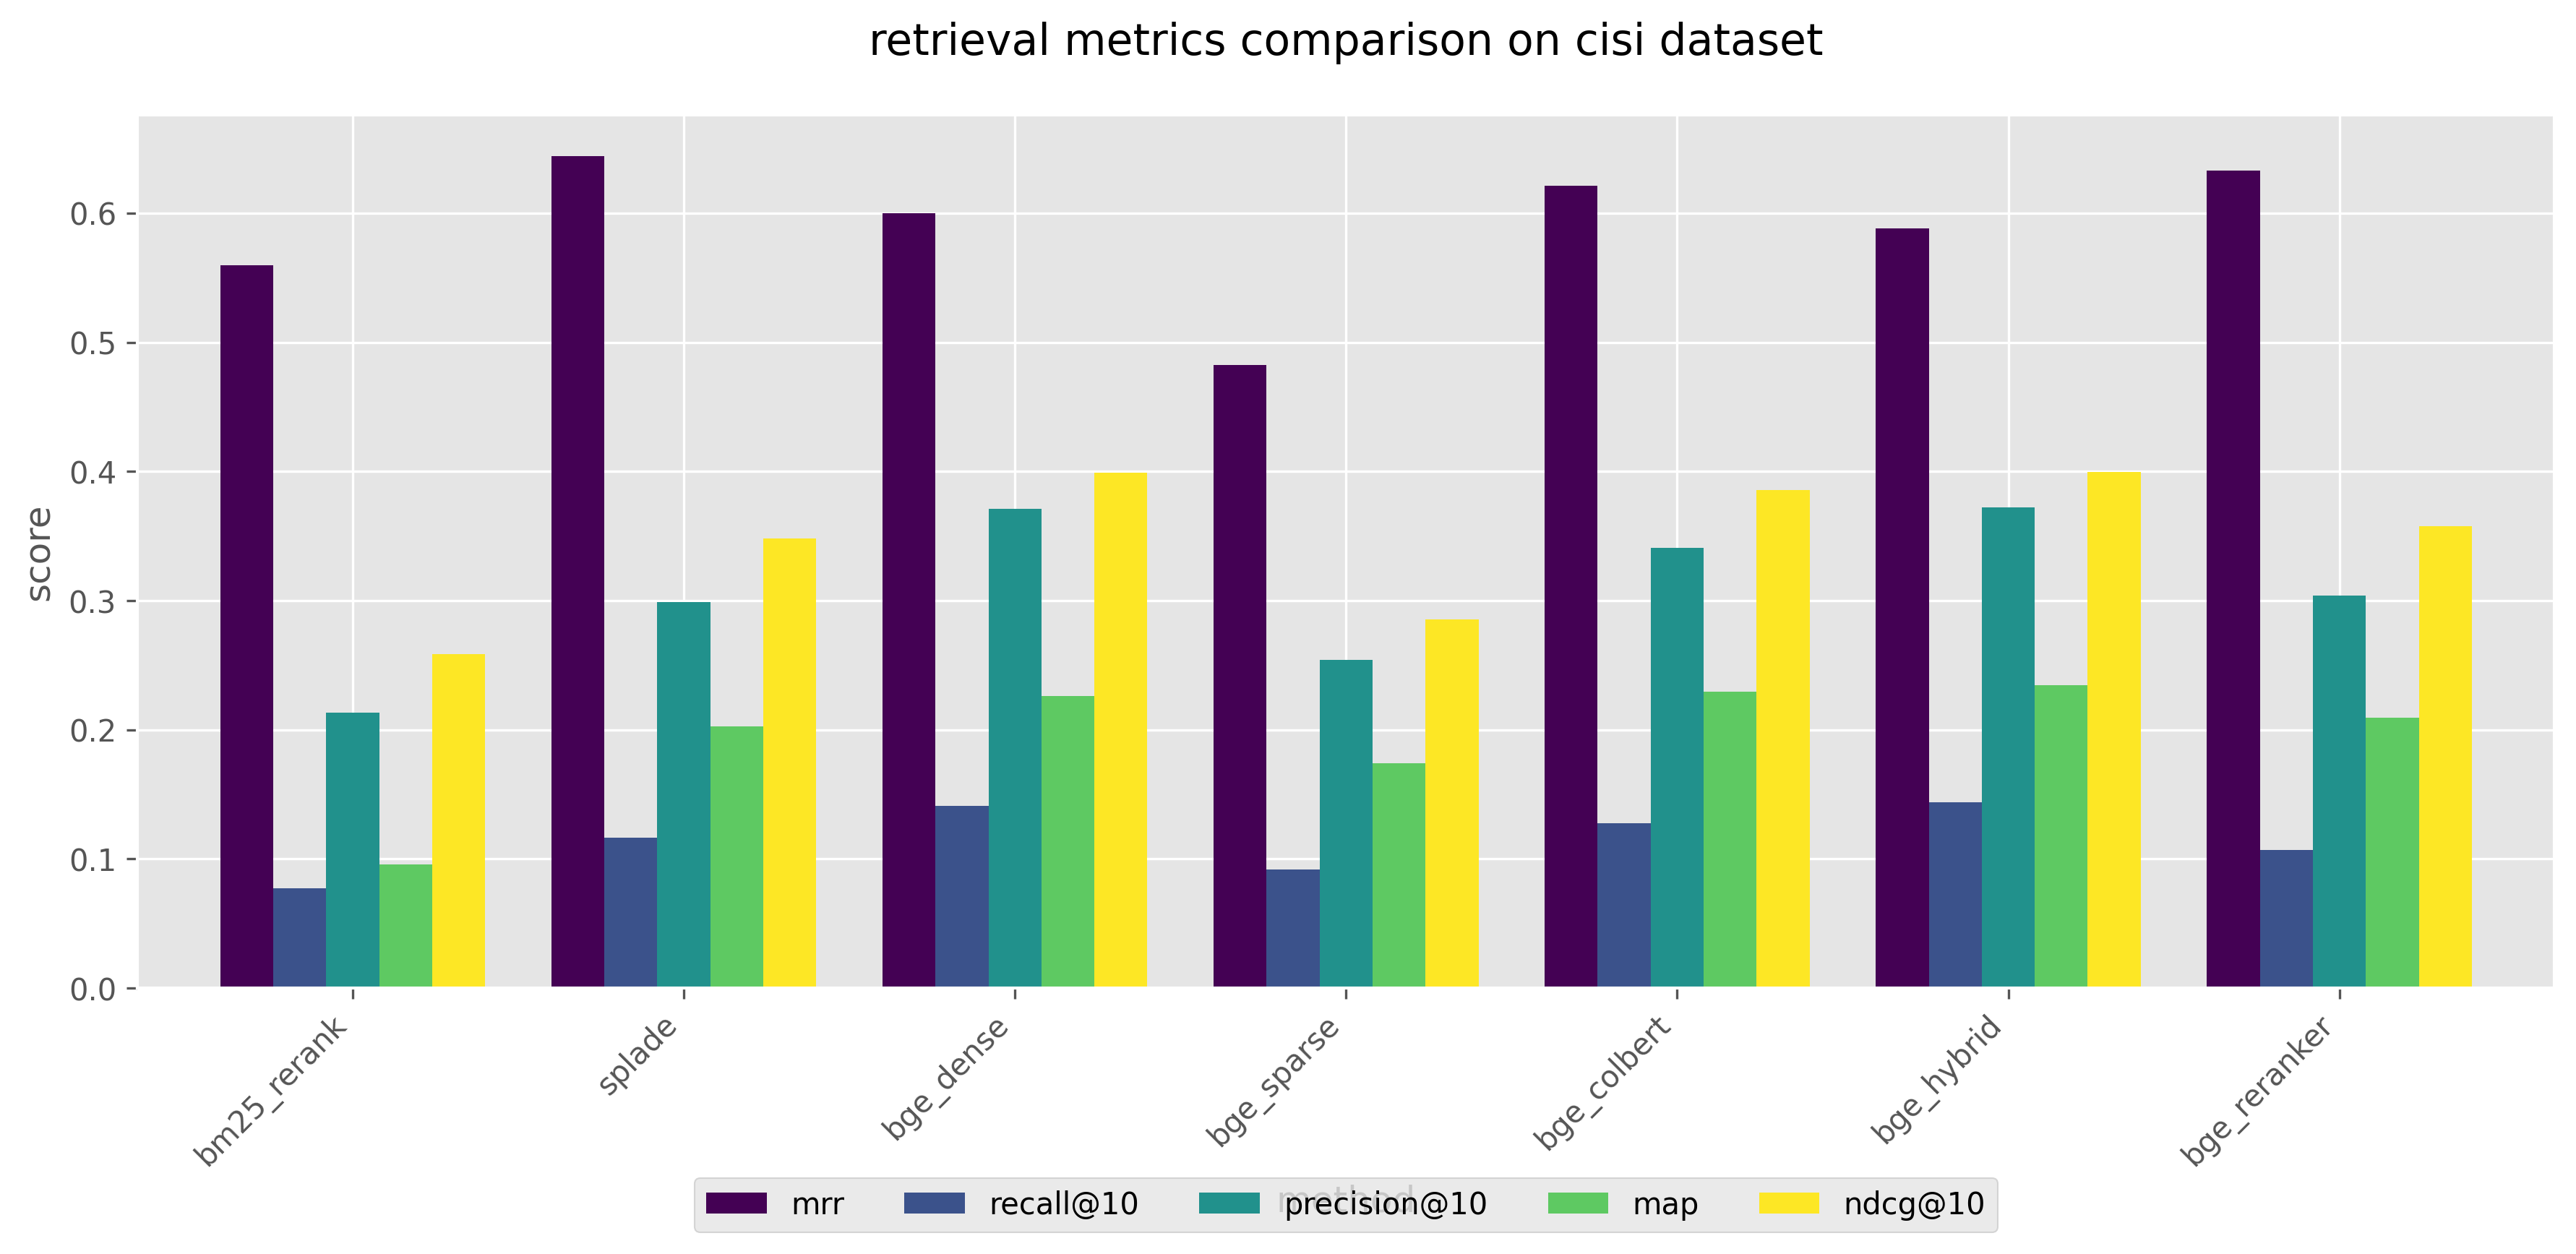

In [ ]:
from PIL import Image

Image.open('cisi_eval_metrics.png')

In [ ]:
!python benchagentic.py

2026-03-24 22:01:41.025517: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 22:01:41.044698: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774389701.067341    8784 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774389701.074777    8784 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774389701.094124    8784 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

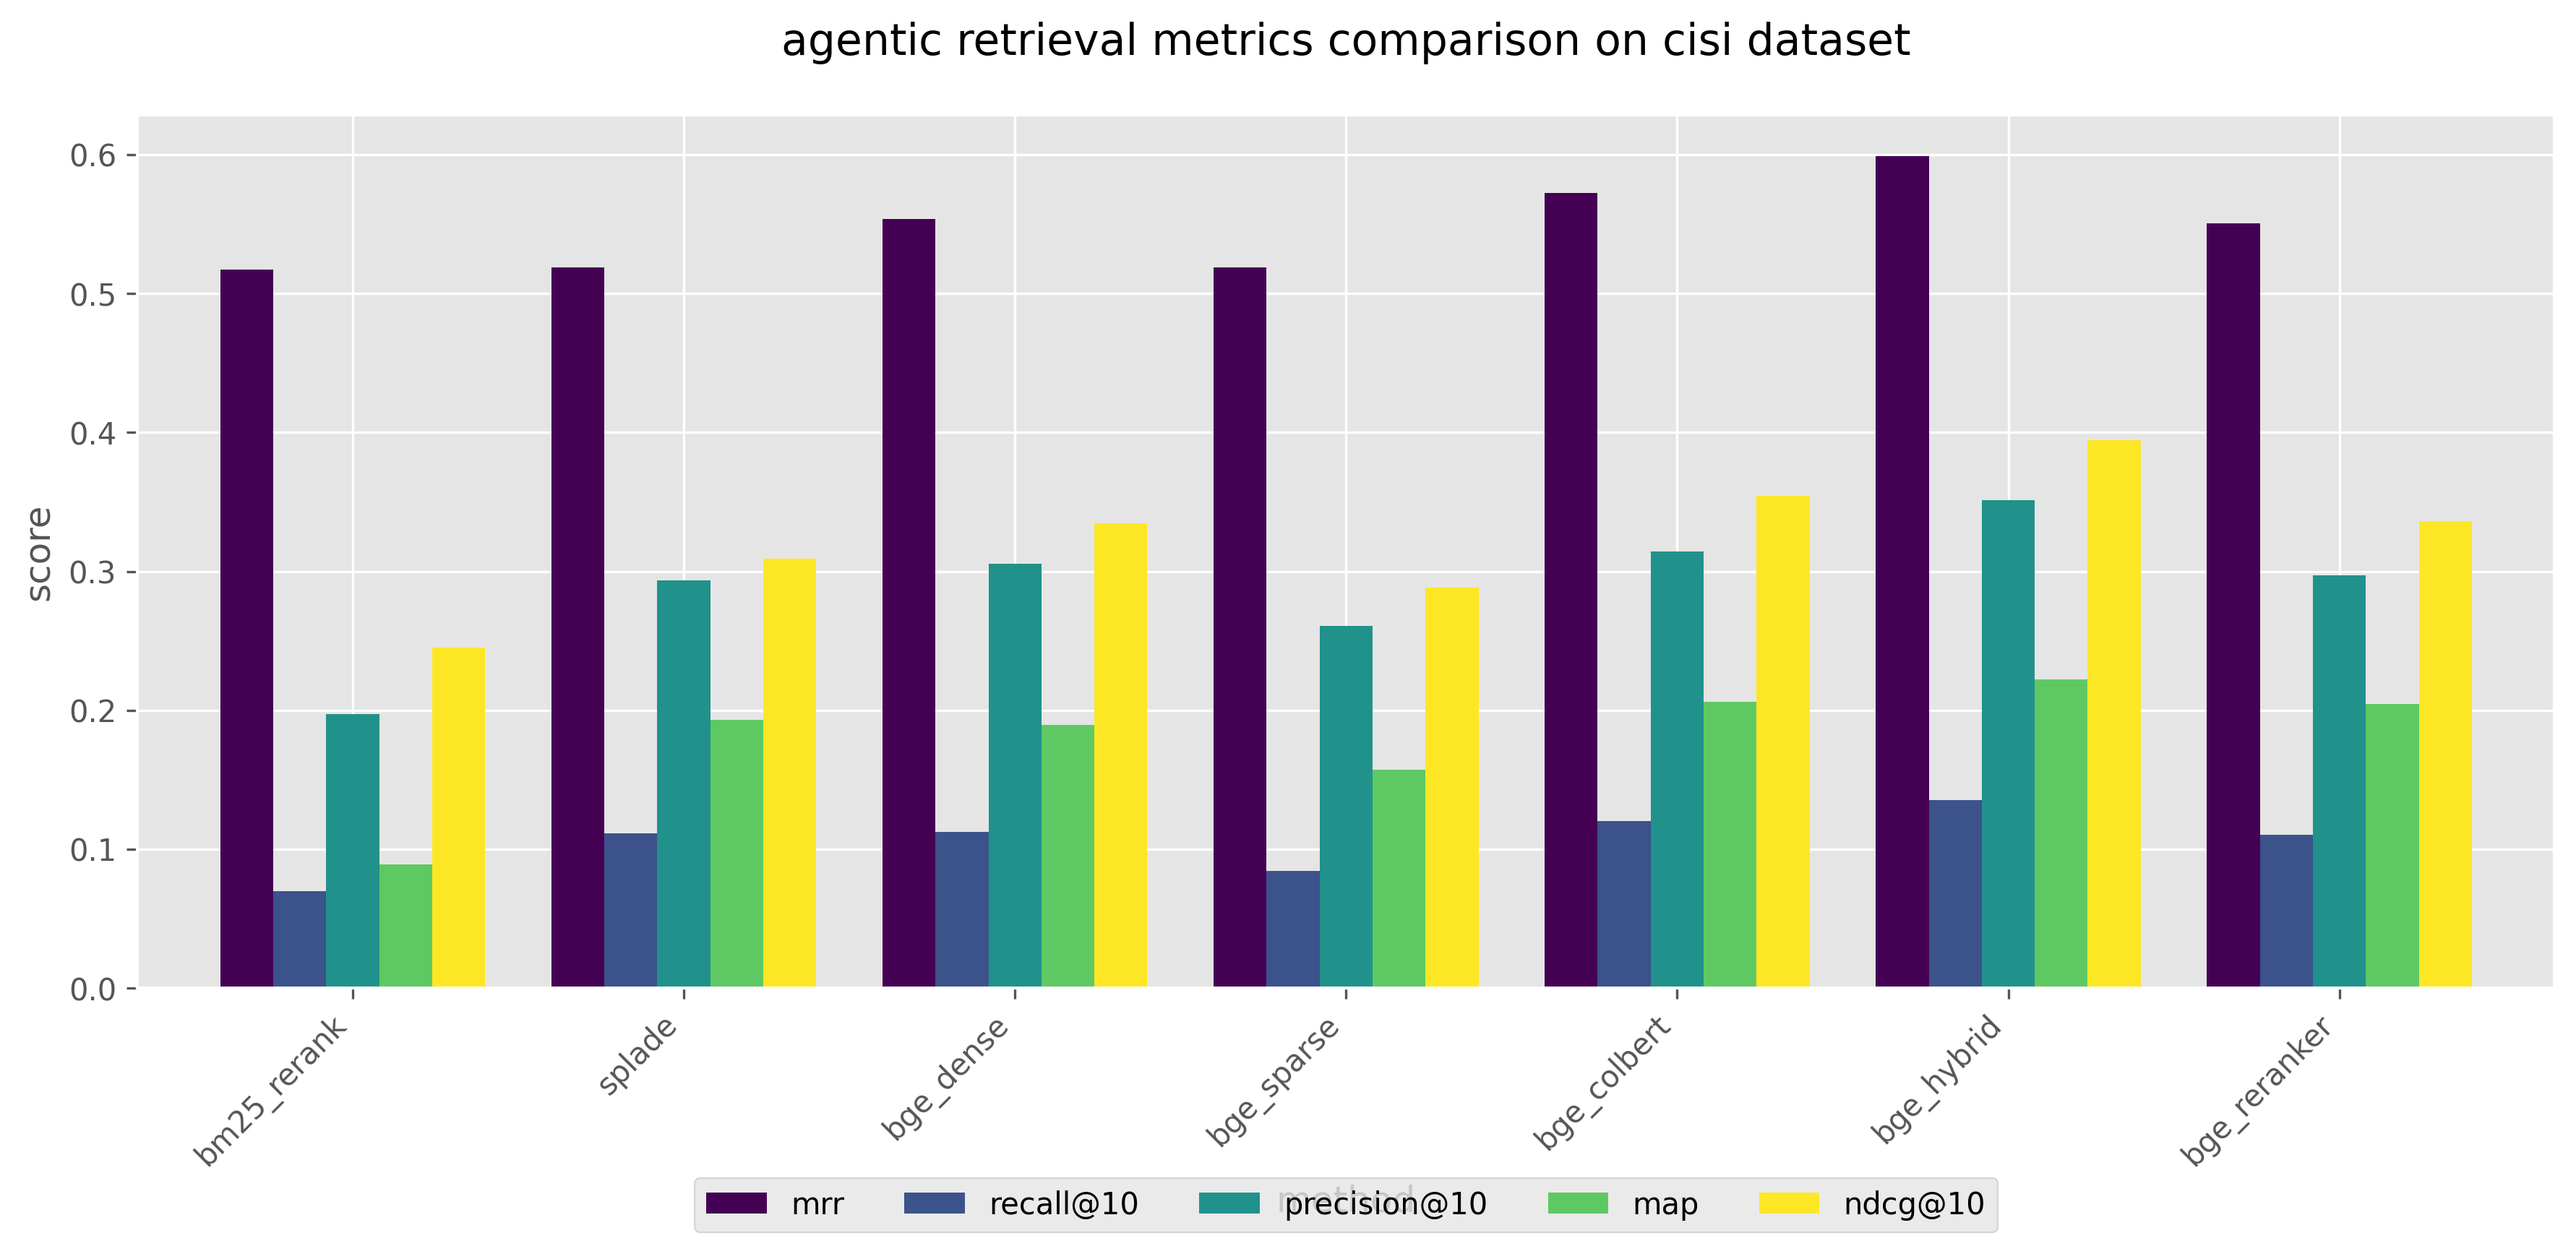

In [ ]:
from PIL import Image

Image.open('cisi_agent_eval_metrics.png')